# GeoPandas: Mapping & Spatial Data

This notebook introduces **GeoPandas** — a Python library that extends pandas with spatial data types and operations — using a real **UK regions** shapefile.

## Contents
1. Reading a shapefile — UK regions
2. Exploring the GeoDataFrame
3. Choropleth map (colour by value)
4. Styled map with TG colours
5. Layered map — regions + cities
6. **Your Turn** — build your own analysis

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
from shapely.geometry import Point

import sys
sys.path.insert(0, '..')
from template import setup_matplotlib_template, get_colors, get_cmap

# Apply TG house style
setup_matplotlib_template('TG')
TG_COLORS = get_colors('TG')
tg_cmap = get_cmap('TG')

Century Gothic font loaded successfully from resources folder
Finlandica font loaded successfully
Make sure that you have the Finlandica font installed on your system by double/right clicking the .ttf file and press install.


---
## 1. Reading a Shapefile — UK Regions

A **shapefile** is a common geospatial file format. It consists of several files (`.shp`, `.shx`, `.dbf`, `.prj`) that together define both the geometry and the attribute data.

GeoPandas reads them with `gpd.read_file()`.

In [ ]:
# Read the UK regions shapefile
gdf_regions = gpd.read_file('../assets/UK_counties/georef-united-kingdom-region-millesime.shp')

gdf_regions

---
## 2. Exploring the GeoDataFrame

Let's clean up the data and understand what we're working with.

In [7]:
# The column values have square brackets — clean them up
for col in ['ctry_code', 'ctry_name', 'rgn_code', 'rgn_name']:
    gdf_regions[col] = gdf_regions[col].str.strip("[]'")

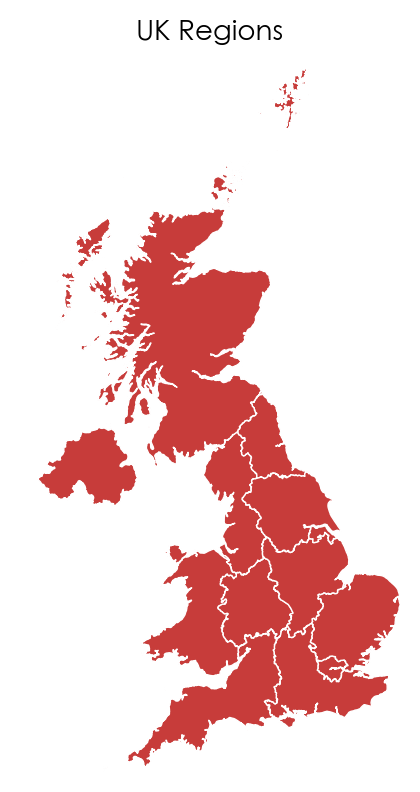

In [9]:
# Quick plot
fig, ax = plt.subplots(figsize=(3, 4))
gdf_regions.plot(ax=ax, color=TG_COLORS[0], edgecolor='white', linewidth=0.5)
ax.set_title('UK Regions')
ax.axis('off')
plt.tight_layout()
plt.show()

---
## 3. Choropleth Map (Colour by Value)

A **choropleth** colours each region according to a numeric value. We'll create some made-up data and merge it onto the GeoDataFrame.

In [10]:
# Made-up regional statistics
region_stats = pd.DataFrame({
    'rgn_name': ['London', 'South East', 'South West', 'East of England',
                 'West Midlands', 'East Midlands', 'North West',
                 'Yorkshire and The Humber', 'North East',
                 'Scotland', 'Wales', 'Northern Ireland'],
    'projects':     [152, 87, 64, 71, 58, 43, 76, 51, 32, 68, 37, 24],
    'funding_m':    [385, 195, 142, 168, 130, 98, 178, 115, 72, 155, 85, 54],
    'universities': [40,  18,  12,  10,  13,   9,  16,  11,   5,  15,   8,   4],
})
region_stats

,rgn_name,projects,funding_m,universities
0,London,152,385,40
1,South East,87,195,18
2,South West,64,142,12
3,East of England,71,168,10
4,West Midlands,58,130,13
5,East Midlands,43,98,9
6,North West,76,178,16
7,Yorkshire and The Humber,51,115,11
8,North East,32,72,5
9,Scotland,68,155,15


In [11]:
# Merge onto the GeoDataFrame
gdf = gdf_regions.merge(region_stats, on='rgn_name', how='left')
gdf

,year,ctry_code,ctry_name,rgn_code,rgn_name,rgn_area_co,rgn_type,geometry,projects,funding_m,universities
0,2022,E92000001,England,E12000007,London,GBR,region,"POLYGON ((0.2031 51.45794, 0.20333 51.45433, 0...",152,385,40
1,2022,E92000001,England,E12000005,West Midlands,GBR,region,"POLYGON ((-1.33191 52.16847, -1.33391 52.15927...",58,130,13
2,2022,E92000001,England,E12000006,East of England,GBR,region,"MULTIPOLYGON (((0.64511 51.5393, 0.64641 51.53...",71,168,10
3,2022,E92000001,England,E12000008,South East,GBR,region,"MULTIPOLYGON (((-1.31199 50.76733, -1.3016 50....",87,195,18
4,2022,E92000001,England,E12000002,North West,GBR,region,"MULTIPOLYGON (((-3.24581 54.09324, -3.23487 54...",76,178,16
5,2022,E92000001,England,E12000001,North East,GBR,region,"MULTIPOLYGON (((-1.86212 55.69792, -1.85081 55...",32,72,5
6,2022,E92000001,England,E12000004,East Midlands,GBR,region,"MULTIPOLYGON (((0.26743 52.8132, 0.26224 52.80...",43,98,9
7,2022,N92000002,Northern Ireland,N92000002,Northern Ireland,GBR,region,"MULTIPOLYGON (((-5.53486 54.68176, -5.53069 54...",24,54,4
8,2022,E92000001,England,E12000003,Yorkshire and The Humber,GBR,region,"MULTIPOLYGON (((-0.55371 53.69031, -0.54617 53...",51,115,11
9,2022,S92000003,Scotland,S92000003,Scotland,GBR,region,"MULTIPOLYGON (((-5.11377 55.25632, -5.10713 55...",68,155,15


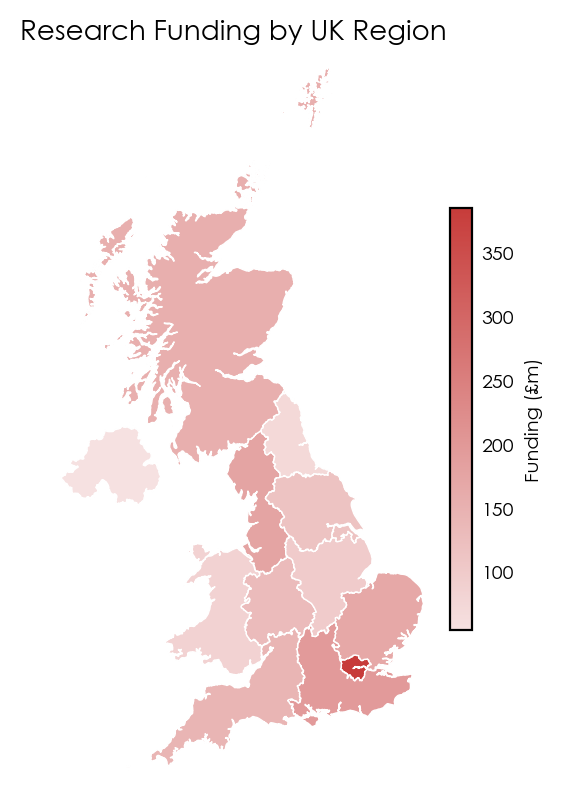

In [12]:
# Choropleth — colour by total funding
fig, ax = plt.subplots(figsize=(3, 4))
gdf.plot(ax=ax, column='funding_m', cmap=tg_cmap, edgecolor='white',
         linewidth=0.5, legend=True,
         legend_kwds={'label': 'Funding (£m)', 'shrink': 0.6})

ax.set_title('Research Funding by UK Region')
ax.axis('off')
plt.tight_layout()
plt.show()

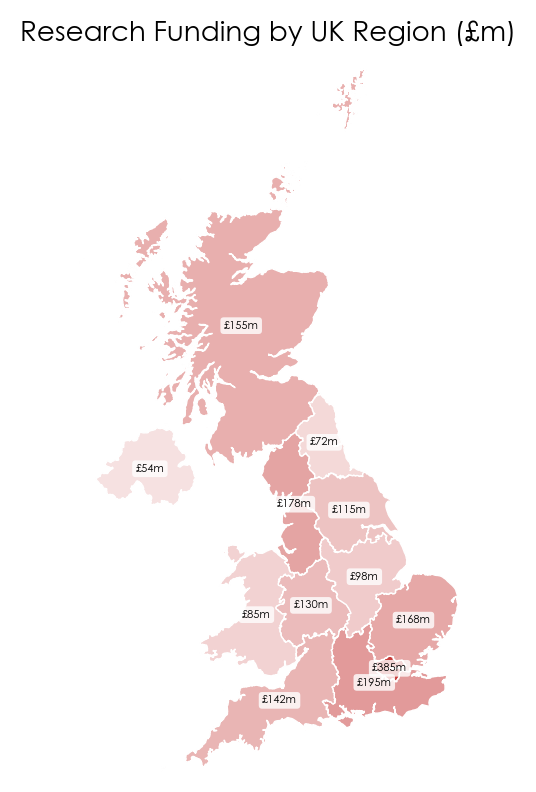

In [13]:
# Flat colour map with funding amounts annotated on each region
fig, ax = plt.subplots(figsize=(3, 4))
gdf.plot(ax=ax, column='funding_m', cmap=tg_cmap, edgecolor='white', linewidth=0.5)

for _, row in gdf.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(f"£{row['funding_m']:.0f}m",
                xy=(centroid.x, centroid.y),
                ha='center', va='center', fontsize=4, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='none'))

ax.set_title('Research Funding by UK Region (£m)')
ax.axis('off')
plt.tight_layout()
plt.show()

In [24]:
# Create label position columns from centroids — you can edit these to reposition labels
gdf['label_x'] = gdf.geometry.centroid.x
gdf['label_y'] = gdf.geometry.centroid.y

# Uncomment and tweak to nudge specific labels, e.g.:
gdf.loc[gdf['rgn_name'] == 'London', 'label_x'] += 1
# gdf.loc[gdf['rgn_name'] == 'London', 'label_y'] -= 0.3

gdf.loc[gdf['rgn_name'] == 'South East', 'label_y'] -= 0.2

gdf[['rgn_name', 'label_x', 'label_y']]

/var/folders/j9/h0b6mmmn4bvbwj0wqc2fywh40000gp/T/ipykernel_93817/2562888273.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['label_x'] = gdf.geometry.centroid.x
/var/folders/j9/h0b6mmmn4bvbwj0wqc2fywh40000gp/T/ipykernel_93817/2562888273.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['label_y'] = gdf.geometry.centroid.y


,rgn_name,label_x,label_y
0,London,0.888566,51.500531
1,West Midlands,-2.270801,52.480304
2,East of England,0.539272,52.251144
3,South East,-0.534064,51.080892
4,North West,-2.723378,54.056519
5,North East,-1.905171,55.019980
6,East Midlands,-0.805616,52.926990
7,Northern Ireland,-6.683128,54.608357
8,Yorkshire and The Humber,-1.229534,53.965458
9,Scotland,-4.181587,56.837153


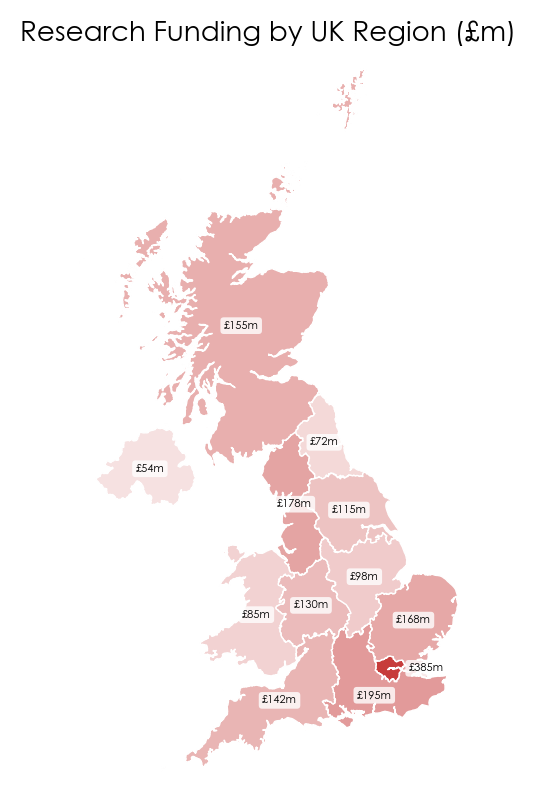

In [25]:
# Re-plot using the editable label positions
fig, ax = plt.subplots(figsize=(3, 4))
gdf.plot(ax=ax, column='funding_m', cmap=tg_cmap, edgecolor='white', linewidth=0.5)

for _, row in gdf.iterrows():
    ax.annotate(f"£{row['funding_m']:.0f}m",
                xy=(row['label_x'], row['label_y']),
                ha='center', va='center', fontsize=4, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='none'))

ax.set_title('Research Funding by UK Region (£m)')
ax.axis('off')
plt.tight_layout()
plt.show()

---
## Your Turn — CORDIS Funding by Country

Using what you've learned above, create a **choropleth map of Europe** showing EU research funding per country.

### Data
- **CORDIS organisations**: `../assets/cordis_orgs.csv` — one row per organisation per project, with columns `vatNumber`, `ecContribution`, `masterCall`, etc.
- **Europe shapefile**: `../assets/europe_countries/world-administrative-boundaries.shp` — 52 European countries with an `iso_3166_1_` column (2-letter country code like `FR`, `DE`)

### Steps

1. **Load the CORDIS data** and filter to a single master call (e.g. `'HORIZON-CL5-2022-D2-01'`)
2. **Extract the country code** from the first 2 letters of `vatNumber`:
   ```python
   df['country'] = df['vatNumber'].str.extract(r'^([A-Z]{2})')
   ```
3. **Aggregate funding per country**:
   ```python
   funding_by_country = df.groupby('country')['ecContribution'].sum().reset_index()
   funding_by_country.columns = ['iso_3166_1_', 'total_funding']
   ```
4. **Load the Europe shapefile** and merge the funding data onto it using `iso_3166_1_` as the join key
5. **Plot a choropleth** coloured by `total_funding`
6. **Annotate** with country names or funding amounts — use the `label_x` / `label_y` centroid trick from above to position them

### Bonus ideas
- Convert funding to millions (`total_funding / 1e6`) for cleaner labels
- Count number of unique organisations per country and map that instead
- Create a side-by-side: funding on the left, number of orgs on the right